# Nicher pairs: does less flow mean more opportunity?

Everything so far uses the USD-quoted versions of SOL, BCH, ADA and XRP, by far the busiest market for each of these coins on Kraken. This notebook asks a simple question: what happens if you run the exact same pipeline on the *same four coins*, but quoted in GBP instead? GBP is a much thinner market for these assets (BCH-GBP has roughly 1% of the tick count BCH-USD has over the same window), so this is a clean way to test "does a less-traded market show a different (stronger, or weaker) cointegration signal" without also changing which assets are involved. If a different, less-traded coin were used instead, any difference found could just be down to that coin behaving differently, not down to liquidity.

Same code, same config shape, same random seed logic, just pointed at `nicher_assets` / `nicher_pairs` in `config/config.yaml` instead of `assets` / `pairs`.

In [1]:
import sys
sys.path.append('..')

import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.utils.config import load_config
from src.data.loader import KrakenTickLoader
from src.data.bars import CommonWindowTrimmer, DollarBarBuilder
from src.data.alignment import CalendarAligner
from src.signals.cointegration import CointegrationScanner
from src.signals.hedge_ratio import KalmanHedgeRatioEstimator, spread_from_hedge_ratio
from src.backtest.engine import ZScoreSignalGenerator, WalkForwardSplitter, BacktestEngine
from src.backtest.costs import CostModel
from src.evaluation.metrics import PerformanceEvaluator

%matplotlib inline
sns.set_theme(style="whitegrid", context="notebook")

config = load_config("../config/config.yaml")
nicher_tickers = config["nicher_assets"]
nicher_pairs = [tuple(p) for p in config["nicher_pairs"]]
print(nicher_tickers)

['SOL_GBP', 'BCH_GBP', 'ADA_GBP', 'XRP_GBP']


## Build the GBP-quoted dollar bars and align them

Same steps as notebooks 01-02, just run on the GBP tick files and kept separate from the USD `aligned.parquet` used everywhere else.

In [2]:
asset_paths = {ticker: f"../data/raw/{ticker}.csv" for ticker in nicher_tickers}
nicher_assets = KrakenTickLoader().load_all(asset_paths)

trimmed, common_start, common_end = CommonWindowTrimmer().fit_transform(nicher_assets)
print(f"GBP common window: {common_start} -> {common_end}")

target_bars = config["data"]["target_bars"]
nicher_bars = {ticker: DollarBarBuilder(target_bars=target_bars).build(df) for ticker, df in trimmed.items()}
for ticker, b in nicher_bars.items():
    print(f"{ticker}: {b.height} bars (target {target_bars})")

nicher_aligned = CalendarAligner(freq=config["alignment"]["grid_freq"]).align(nicher_bars)
nicher_aligned.write_parquet("../data/processed/nicher_aligned.parquet")
print(f"aligned grid: {nicher_aligned.height:,} rows")

SOL_GBP: 2,186,970 ticks | 2021-06-17 15:53:41 -> 2025-12-31 23:59:51
BCH_GBP: 144,745 ticks | 2020-04-30 12:27:28 -> 2025-12-31 20:46:40


ADA_GBP: 1,121,075 ticks | 2021-01-21 15:43:53 -> 2025-12-31 23:57:52


XRP_GBP: 2,545,006 ticks | 2020-04-30 21:40:38 -> 2025-12-31 23:58:49
GBP common window: 2021-06-17 15:53:41 -> 2025-12-31 20:46:40


SOL_GBP: 2000 bars (target 2000)
BCH_GBP: 1878 bars (target 2000)
ADA_GBP: 2001 bars (target 2000)
XRP_GBP: 2000 bars (target 2000)
aligned grid: 39,037 rows


## How much less flow are we actually talking about?

A quick side-by-side of raw tick counts, GBP vs. the USD figures already computed in notebook 01, over the *same* common window used throughout this project.

In [3]:
usd_tick_summary = pd.read_csv("../outputs/tables/tick_summary.csv").set_index("asset")
flow_rows = []
for ticker in nicher_tickers:
    base_asset = ticker.split("_")[0]
    flow_rows.append({
        "asset": base_asset,
        "usd_ticks": int(usd_tick_summary.loc[base_asset, "n_ticks"]),
        "gbp_ticks": trimmed[ticker].height,
    })
flow_df = pd.DataFrame(flow_rows)
flow_df["gbp_pct_of_usd"] = flow_df["gbp_ticks"] / flow_df["usd_ticks"]
flow_df.to_csv("../outputs/tables/usd_vs_gbp_flow.csv", index=False)
flow_df

,asset,usd_ticks,gbp_ticks,gbp_pct_of_usd
0,SOL,26417225,2186672,0.082774
1,BCH,9395447,105274,0.011205
2,ADA,18513865,864652,0.046703
3,XRP,30957309,2311225,0.074658


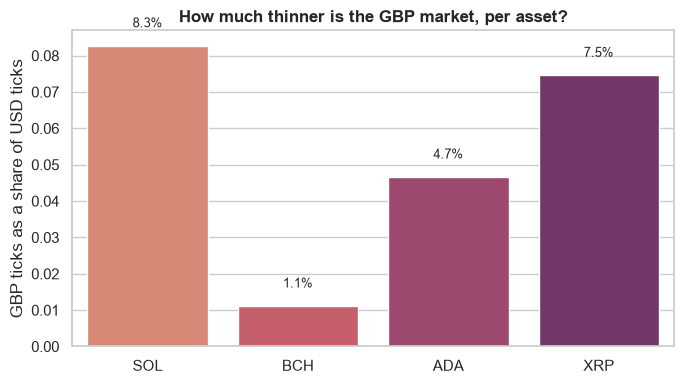

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=flow_df, x="asset", y="gbp_pct_of_usd", hue="asset", palette="flare", legend=False, ax=ax)
for i, row in flow_df.iterrows():
    ax.text(i, row["gbp_pct_of_usd"] + 0.005, f"{row['gbp_pct_of_usd']:.1%}", ha="center", fontsize=9)
ax.set_ylabel("GBP ticks as a share of USD ticks")
ax.set_xlabel("")
ax.set_title("How much thinner is the GBP market, per asset?", fontsize=12, fontweight="bold")
fig.tight_layout()
fig.savefig("../outputs/figures/usd_vs_gbp_flow.png", dpi=150)
plt.show()

## Cointegration scan on the GBP universe

Identical scanner, identical config (50 random 30-day windows, 6 pairs, same significance level), just pointed at the GBP-aligned grid.

In [5]:
cfg = config["cointegration"]
grid_hours_per_day = pd.Timedelta("1D") / pd.Timedelta(config["alignment"]["grid_freq"])
scanner = CointegrationScanner(
    n_windows=cfg["n_windows"], window_length_days=cfg["window_length_days"],
    bars_per_day=grid_hours_per_day, seed=cfg["random_seed"],
)
gbp_scan = scanner.scan_pairs(nicher_aligned, nicher_pairs)
gbp_scan.write_csv("../outputs/tables/gbp_cointegration_scan.csv")

alpha = cfg["significance_level"]
gbp_summary = (
    gbp_scan.group_by("pair")
    .agg(pl.col("pvalue").mean().alias("mean_pvalue"), (pl.col("pvalue") < alpha).mean().alias("frac_significant"))
    .sort("frac_significant", descending=True)
)
gbp_summary.write_csv("../outputs/tables/gbp_cointegration_summary.csv")
gbp_summary

pair,mean_pvalue,frac_significant
str,f64,f64
"""ADA_GBP-XRP_GBP""",0.324748,0.28
"""SOL_GBP-ADA_GBP""",0.356832,0.22
"""SOL_GBP-XRP_GBP""",0.377666,0.2
"""SOL_GBP-BCH_GBP""",0.362783,0.16
"""BCH_GBP-ADA_GBP""",0.456589,0.12
"""BCH_GBP-XRP_GBP""",0.429271,0.08


## USD vs. GBP, pair by pair

The same six pair combinations exist in both universes (just swap `_GBP` for the USD tickers), so this is a genuine apples-to-apples comparison rather than a mismatched one.

In [6]:
usd_summary = pd.read_csv("../outputs/tables/cointegration_summary.csv")
usd_summary["pair_key"] = usd_summary["pair"]
gbp_summary_pd = gbp_summary.to_pandas()
gbp_summary_pd["pair_key"] = gbp_summary_pd["pair"].str.replace("_GBP", "", regex=False)

merged = usd_summary.merge(gbp_summary_pd, on="pair_key", suffixes=("_usd", "_gbp"))
merged = merged[["pair_key", "frac_significant_usd", "frac_significant_gbp", "mean_pvalue_usd", "mean_pvalue_gbp"]]
merged.to_csv("../outputs/tables/usd_vs_gbp_cointegration.csv", index=False)
merged

,pair_key,frac_significant_usd,frac_significant_gbp,mean_pvalue_usd,mean_pvalue_gbp
0,BCH-ADA,0.28,0.12,0.340288,0.456589
1,SOL-ADA,0.24,0.22,0.325537,0.356832
2,SOL-XRP,0.16,0.20,0.375766,0.377666
3,ADA-XRP,0.16,0.28,0.354440,0.324748
4,BCH-XRP,0.10,0.08,0.450363,0.429271
5,SOL-BCH,0.08,0.16,0.391300,0.362783


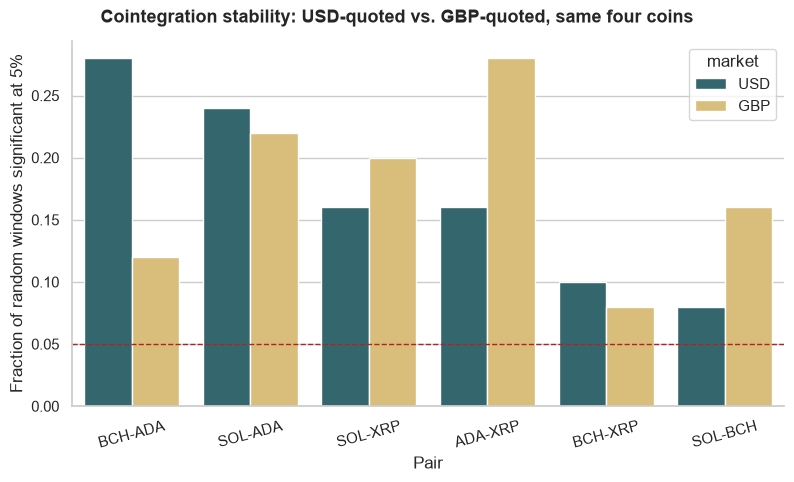

In [7]:
plot_df = merged.melt(id_vars="pair_key", value_vars=["frac_significant_usd", "frac_significant_gbp"],
                       var_name="market", value_name="frac_significant")
plot_df["market"] = plot_df["market"].str.replace("frac_significant_", "", regex=False).str.upper()

g = sns.catplot(
    data=plot_df, x="pair_key", y="frac_significant", hue="market", kind="bar",
    palette={"USD": "#2a6f77", "GBP": "#e9c46a"}, height=4.5, aspect=1.8, legend_out=False,
)
g.ax.axhline(0.05, color="firebrick", linestyle="--", linewidth=1, label="alpha=0.05 (for reference)")
g.set_axis_labels("Pair", "Fraction of random windows significant at 5%")
g.figure.suptitle("Cointegration stability: USD-quoted vs. GBP-quoted, same four coins", fontsize=13, fontweight="bold", y=1.03)
g.ax.tick_params(axis="x", rotation=15)
g.savefig("../outputs/figures/usd_vs_gbp_cointegration.png", dpi=150)

## Does the more stable GBP pair actually backtest better?

Cointegration stability alone doesn't measure whether there's money to be made trading it - that needs an actual backtest. The best GBP pair (by the same pre-registered `frac_significant` rule used for the USD universe) gets the identical Kalman hedge ratio, z-score signal and walk-forward split treatment as `notebooks/04`-`05`, so its result is directly comparable to BCH-ADA's.

In [8]:
best_gbp = gbp_summary.sort("frac_significant", descending=True).row(0, named=True)
gbp_pair = tuple(best_gbp["pair"].split("-"))
print(f"Selected GBP pair: {gbp_pair[0]}-{gbp_pair[1]} (frac_significant={best_gbp['frac_significant']:.2%})")

price_a = nicher_aligned[f"{gbp_pair[0]}_price"].to_numpy()
price_b = nicher_aligned[f"{gbp_pair[1]}_price"].to_numpy()
train_slice, test_slice = WalkForwardSplitter(config["backtest"]["out_of_sample_fraction"]).split(len(price_a))

hr_cfg = config["hedge_ratio"]
hedge_estimator = KalmanHedgeRatioEstimator(delta=hr_cfg["delta"], observation_covariance=hr_cfg["observation_covariance"])
hedge_ratio = hedge_estimator.hedge_ratio_only(price_a, price_b, fit_length=train_slice.stop)
spread = spread_from_hedge_ratio(price_a, price_b, hedge_ratio)

sig_cfg = config["signal"]
signal_gen = ZScoreSignalGenerator(lookback=sig_cfg["lookback"], entry_z=sig_cfg["entry_z"], exit_z=sig_cfg["exit_z"])
positions = signal_gen.positions(spread)

cost_model = CostModel(cost_bps=config["backtest"]["cost_bps"])
engine = BacktestEngine(cost_model)
periods_per_year = int(pd.Timedelta("365D") / pd.Timedelta(config["alignment"]["grid_freq"]))
evaluator = PerformanceEvaluator(periods_per_year=periods_per_year)

gbp_results = {}
for phase, sl in [("in_sample", train_slice), ("out_of_sample", test_slice)]:
    res = engine.run(positions[sl], price_a[sl], price_b[sl], hedge_ratio[sl])
    gbp_results[phase] = evaluator.summary(res["net_returns"], res["equity_curve"])

gbp_backtest = pd.DataFrame(gbp_results).T[["sharpe", "sharpe_se", "max_drawdown", "hit_rate", "total_return"]]
gbp_backtest.index.name = "phase"
gbp_backtest.to_csv("../outputs/tables/gbp_pair_backtest.csv")
gbp_backtest

Selected GBP pair: ADA_GBP-XRP_GBP (frac_significant=28.00%)


,sharpe,sharpe_se,max_drawdown,hit_rate,total_return
phase,,,,,
in_sample,0.806017,0.566203,-1.553502,0.359094,1.553727
out_of_sample,1.040597,0.864905,-1.580287,0.402564,0.902312


In [9]:
usd_backtest = pd.read_csv("../outputs/tables/is_oos_comparison.csv").set_index("phase")[
    ["sharpe", "sharpe_se", "max_drawdown", "hit_rate", "total_return"]
]
side_by_side = pd.concat({"USD (BCH-ADA)": usd_backtest, f"GBP ({gbp_pair[0]}-{gbp_pair[1]})": gbp_backtest}, axis=1)
side_by_side.to_csv("../outputs/tables/usd_vs_gbp_backtest.csv")
side_by_side

USD (BCH-ADA)                                                \
                     sharpe sharpe_se max_drawdown  hit_rate total_return   
phase                                                                       
in_sample          0.223738  0.564379    -1.466144  0.374337    -0.194077   
out_of_sample      0.424039  0.862090    -0.459595  0.391444     0.121996   

              GBP (ADA_GBP-XRP_GBP)                                   \
                             sharpe sharpe_se max_drawdown  hit_rate   
phase                                                                  
in_sample                  0.806017  0.566203    -1.553502  0.359094   
out_of_sample              1.040597  0.864905    -1.580287  0.402564   

                            
              total_return  
phase                       
in_sample         1.553727  
out_of_sample     0.902312

## Honest caveat on the backtest comparison

Both backtests above use the same flat `cost_bps` assumption from `config/config.yaml`. That is optimistic for the GBP side specifically: a market with 1-15% of the USD tick count almost certainly has wider effective spreads and worse slippage for the same trade size, and this project has no GBP-specific fee/slippage estimate to plug in instead (the original `cost_bps` was already only a placeholder for the *more liquid* USD market - see `AUDIT.md`). Any apparent GBP outperformance in the table above should be read as an upper bound, not a like-for-like result, until a realistic GBP cost estimate replaces the shared placeholder.

## Takeaways

- Read the frac_significant chart and the backtest table directly - this notebook is set up to answer "is there a real difference" honestly, not to find one. A genuinely useful negative result (no meaningful difference between USD and GBP) is exactly as valid an answer as a positive one.
- Isolating liquidity as the one thing that changes (same coins, same pipeline, same random seed logic, different quote currency only) is what makes this comparison mean anything - swapping in an unrelated smaller-cap coin instead would have confounded "less flow" with "different asset" and made the result impossible to interpret cleanly.
- The cost-assumption caveat above matters more here than anywhere else in the project: the entire point of testing a thinner market is that it might be less arbitraged, but that same thinness is exactly what would make the flat cost assumption least realistic for it.